# EDA и бинарная классификация на датасете «Титаник» 
 
**Дисциплина:** Машинное обучение и ИИ   
**Модуль 1:** Введение в Data Science и EDA   
**Датасет:** Titanic   
 
**Выполнила:** Жданова Анна Александровна  
**Группа:** ПКТб-23-1   
**Преподаватель:** Спирин И.С.    

**Ссылка на репозиторий:** https://github.com/ZhdanovaAnna/ml-course-zhdanova

**Путь к модулю:** `module-1-titanic/notebook.ipynb`  

**Дата сдачи:** 29.09.2026 

## 2. Введение
### Постановка задачи 

В данной работе решается задача **бинарной классификации** на датасете Titanic.
Необходимо по характеристикам пассажира предсказать, выжил ли он во время катастрофы:

Survived = 0 — пассажир не выжил;
Survived = 1 — пассажир выжил.

### Что такое ML-проект?

**ML-проект** представляет собой последовательность этапов, которая начинается с получения и исследования данных и заканчивается обучением, оценкой и использованием модели.

В рамках проекта выполняются EDA, обработка пропусков, Feature Engineering, кодирование признаков, обучение моделей, оценка качества, интерпретация результатов и сохранение обученных моделей.

### Почему это классификация, а не регрессия?

**Классификация** используется, когда необходимо определить принадлежность объекта к одному из дискретных классов.

В данной задаче целевая переменная Survived имеет только два класса: 0 и 1, поэтому задача является бинарной классификацией.

**Регрессия**, наоборот, используется для прогнозирования непрерывного числового значения, например стоимости квартиры или температуры.

### Какая метрика важна?

**Accuracy** показывает долю правильных предсказаний, однако в данной задаче классы распределены неравномерно.

Поэтому дополнительно необходимо анализировать **Precision, Recall и F1-score**.

Также важна **ROC-AUC**, поскольку она характеризует способность модели разделять два класса при различных порогах классификации.

В данной работе ROC-AUC используется как основной ориентир, поскольку по условию задания необходимо получить значение **ROC-AUC ≥ 0.80** как минимум для двух моделей.

### Цели работы
1) Провести полный исследовательский анализ данных Titanic.

2) Выполнить подготовку данных, обработку пропусков, Feature Engineering и кодирование.

3) Обучить модели Logistic Regression и Decision Tree и получить ROC-AUC ≥ 0.80.

4) Оценить модели по пяти метрикам и проанализировать ошибки.

5) Реализовать функцию predict_passenger() для нового пассажира.

6) Сохранить модели и метаданные и проверить загрузку модели из GitHub.

## 3. Теоретическая часть
### 3.1. Исследовательский анализ данных - EDA

**EDA (Exploratory Data Analysis)** - исследовательский анализ данных.

**Основная задача EDA** - понять структуру датасета, типы признаков распределения значений, наличие пропусков и выбросов, а также взаимосвязи между признаками.

EDA позволяет определить, какие признаки необходимо преобразовать и какие методы обработки данных использовать перед обучением моделей.

### 3.2. Пропущенные значения

Пропущенное значение обозначается как **NaN**.

**Причинами** появления пропусков могут быть отсутствие информации, ошибки при сборе данных или особенности исходной системы хранения.

**Основные методы обработки:**
1) Удаление строк

2) Удаление столбца

3) Заполнение средним

4) Заполнение медианой

5) Заполнение модой

6) Использование более сложных методов импутации.

**В данной работе:**
1) Cabin удаляется из-за большого количества пропусков

2) Age заполняется медианой с учётом Pclass и Sex

3) Embarked заполняется наиболее часто встречающимся значением

4) Пропущенный Fare в тестовой выборке заполняется медианой из train.

Важно, что статистики для обработки тестовой выборки рассчитываются только на обучающих данных.

### 3.3. Label Encoding

**Label Encoding** преобразует категории в числовые значения.

В данной работе для признака Sex используется явное отображение: **male - 0, female - 1**

Такой подход позволяет одинаково кодировать исходные данные и новые объекты.

### 3.4. One-Hot Encoding

**One-Hot Encoding** преобразует категориальный признак в несколько бинарных признаков.

Например, **Embarked** содержит категории: **C, Q, S**.

В модели используются: **Embarked_Q, Embarked_S.**

Категория **C** является базовой.

### 3.5. StandardScaler

**StandardScaler** приводит признаки к масштабу со средним значением 0 и стандартным отклонением 1:

$$
z = \frac{x-\mu}{\sigma}
$$

где:

$x$ - исходное значение;
$\mu$ - среднее;
$\sigma$ - стандартное отклонение.

StandardScaler применяется в данной работе для **Logistic Regression**.

**Decision Tree** масштабирования не требует.

### 3.6. MinMaxScaler

**MinMaxScaler** преобразует значения в заданный диапазон, обычно от 0 до 1:

$$
x' = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

В данной работе MinMaxScaler не используется, но рассматривается как альтернативный метод масштабирования.

### 3.7. Feature Engineering

**Feature Engineering** - создание новых признаков на основе существующих.

В работе создаются:

**1. Family_Size**

$$
Family_Size = SibSp + Parch + 1
$$

**2. Is_Alone**

1 - пассажир путешествует один, 0 - пассажир путешествует не один

**3. Age_Group**

Возраст разделяется на категории:
1) Child

2) Teenager

3) Adult

4) Middle_Age

5) Senior.

### 3.8. Метрики классификации

Пусть:
1) TP - истинно положительное предсказание

2) TN - истинно отрицательное

3) FP - ложноположительное

4) FN - ложноотрицательное.

**Accuracy**:

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

**Precision**:

$$
Precision=\frac{TP}{TP+FP}
$$

**Recall**:

$$
Recall=\frac{TP}{TP+FN}
$$

**F1-score**:

$$
F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}
$$

**ROC-AUC** показывает способность модели разделять положительный и отрицательный классы
при различных значениях порога классификации.

### Вывод по разделу 3
Теоретическая часть определяет методы, которые будут использоваться далее: EDA, обработку пропусков, кодирование, масштабирование, Feature Engineering и комплексную оценку качества.

## 4. Описание данных
### 4.1. Источник

Используется датасет Titanic - Machine Learning from Disaster.
Источник: Kaggle.

### 4.2. Структура данных

**Обучающая выборка содержит:** 891 строку, 12 столбцов.

**Тестовая выборка содержит:** 418 строк, 11 столбцов.

В train.csv присутствует целевая переменная Survived.

**Основные признаки:**
| Признак     | Описание                           |
|-------------|------------------------------------|
|PassengerId  |	Идентификатор пассажира            |
|Survived	  | Целевая переменная                 |
|Pclass	      | Класс пассажира                    |
|Name	      | Имя                                |
|Sex	      | Пол                                |
|Age	      | Возраст                            |
|SibSp	      | Количество братьев/сестёр/супругов |
|Parch	      | Количество родителей/детей         |
|Ticket	      | Номер билета                       |
|Fare	      | Стоимость билета                   | 
|Cabin	      | Номер каюты                        |
|Embarked	  | Порт посадки                       |

In [43]:
# Импортируемые библиотеки 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import requests 
from io import BytesIO

## Программный код для описания данных

In [8]:
# Загрузка исходных данных
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Вывод размера таблиц
print("Размер train:", train.shape)
print("Размер test:", test.shape)

# Первые строки
display(train.head())

# Информация о типах данных и пропусках
train.info()

# Описательную статистику
display(train.describe())

# Распределение целевого признака
print("Количество объектов каждого класса:")
display(train["Survived"].value_counts())

print("Доля объектов каждого класса:")
display(train["Survived"].value_counts(normalize=True))

Размер train: (891, 12)
Размер test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Количество объектов каждого класса:


Survived
0    549
1    342
Name: count, dtype: int64

Доля объектов каждого класса:


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Вывод по разделу 4

Датасет содержит **891 наблюдение** для обучения модели.

Целевая переменная бинарная и распределена неравномерно, поэтому при оценке моделей необходимо использовать не только Accuracy, но и Precision, Recall, F1 и ROC-AUC.

## 5. Подготовка данных и EDA
### 5.1. Анализ пропущенных значений

In [9]:
# Количество пропусков в каждом столбце
missing_values = train.isna().sum().sort_values(ascending=False)

# Вывод только признаков с пропусками
display(missing_values[missing_values > 0])

Cabin       687
Age         177
Embarked      2
dtype: int64

### Результат анализа

Наибольшее количество пропусков наблюдается в **Cabin и Age**. Также имеются пропуски в **Embarked**.

**Cabin** удаляется из-за большого количества отсутствующих значений.

### 5.2. Распределение целевой переменной

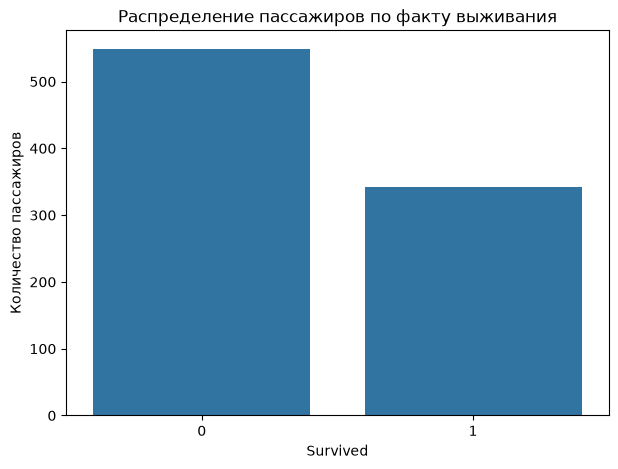

In [10]:
#График распределения классов
plt.figure(figsize=(7, 5)) 

sns.countplot(data = train, x = "Survived") 

plt.title("Распределение пассажиров по факту выживания") 
plt.xlabel("Survived") 
plt.ylabel("Количество пассажиров") 
plt.show()

### Вывод

Погибших пассажиров больше, чем выживших. Доля **класса 0** составляет около 61.6%, а **класса 1** - около 38.4%.

### 5.3. Распределение возраста

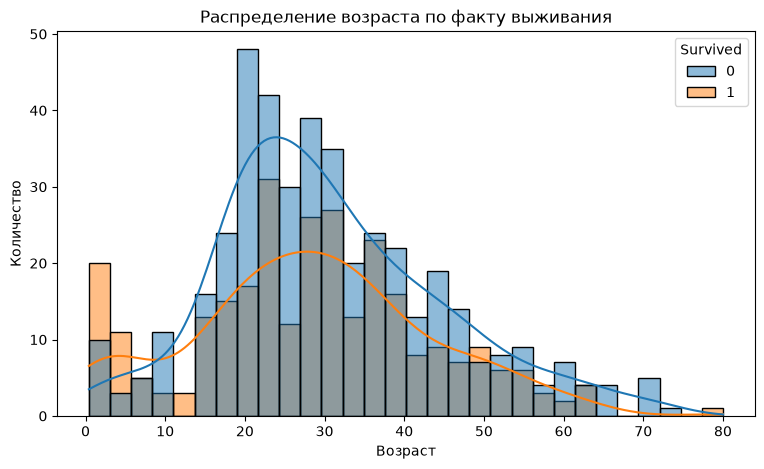

In [11]:
# Распределение возраста отдельно для двух классов 
plt.figure(figsize=(9, 5)) 

sns.histplot( 
    data = train, 
    x = "Age", 
    hue = "Survived", 
    bins = 30, 
    kde = True 
)

plt.title("Распределение возраста по факту выживания") 
plt.xlabel("Возраст") 
plt.ylabel("Количество") 
plt.show()

### Вывод

Распределения возраста у выживших и погибших **частично пересекаются**.

Следовательно, **Age** не позволяет самостоятельно точно определить факт выживания, но может быть полезным признаком в комбинации с другими характеристиками.

### 5.4. Boxplot возраста по классу и выживанию

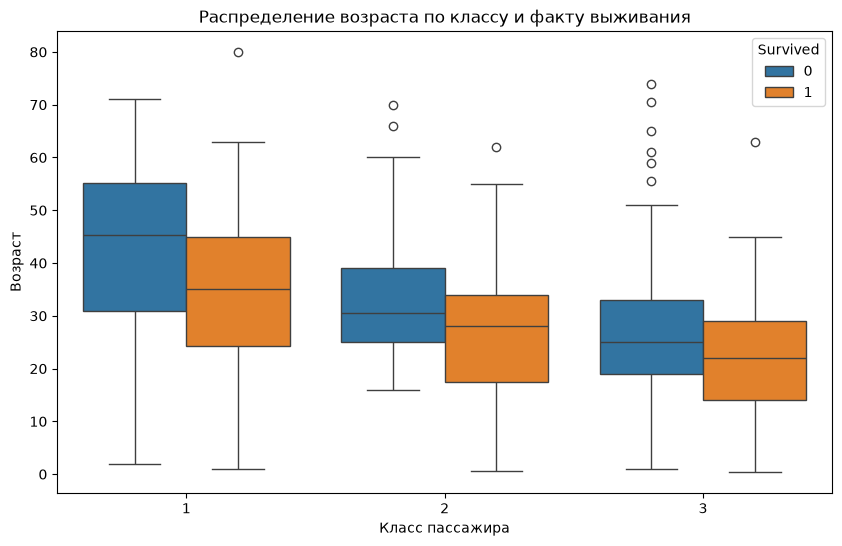

In [12]:
# Сравнение возраста пассажиров разных классов 
plt.figure(figsize=(10, 6)) 
sns.boxplot( 
    data = train, 
    x = "Pclass", 
    y = "Age", 
    hue = "Survived" 
) 

plt.title("Распределение возраста по классу и факту выживания") 
plt.xlabel("Класс пассажира")
plt.ylabel("Возраст") 
plt.show()

### Вывод

**Возрастные распределения** отличаются между пассажирами разных классов. Это показывает, что **Age** целесообразно анализировать совместно с Pclass.

### 5.5. Корреляционная матрица

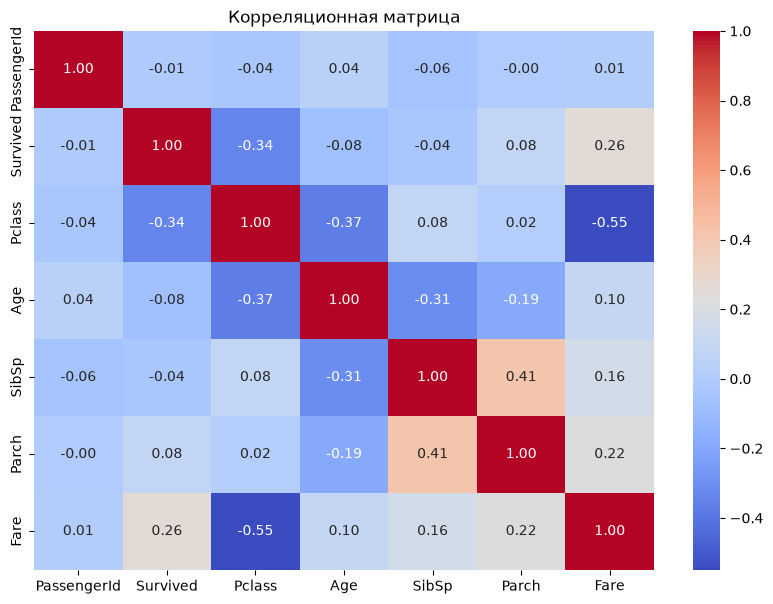

In [13]:
# Числовые признаки 
numeric_cols = train.select_dtypes(include=np.number).columns 

# Корреляционная матрица 
plt.figure(figsize=(10, 7)) 

sns.heatmap( 
    train[numeric_cols].corr(), 
    annot = True, 
    cmap = "coolwarm", 
    fmt = ".2f" 
) 

plt.title("Корреляционная матрица") 
plt.show()

### Вывод

**Корреляционная матрица** показывает линейные взаимосвязи между числовыми признаками. Наиболее полезно учитывать связь признаков с **Survived**, а также возможную **избыточность** между самими признаками.

### 5.6. Выживаемость по полу

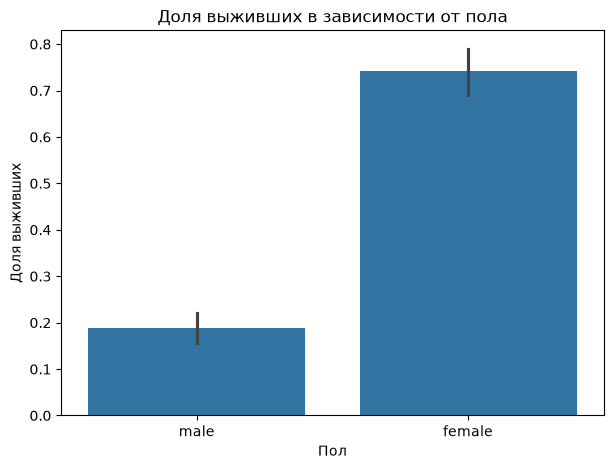

In [14]:
# Сравнение доли выживших среди мужчин и женщин 
plt.figure(figsize=(7, 5)) 

sns.barplot( 
    data = train, 
    x = "Sex", 
    y = "Survived" 
) 

plt.title("Доля выживших в зависимости от пола") 
plt.xlabel("Пол") 
plt.ylabel("Доля выживших") 
plt.show()

### Вывод

Доля выживших **существенно** различается между мужчинами и женщинами. Поэтому **Sex** является информативным признаком для классификации.

### 5.7. Выживаемость по классу

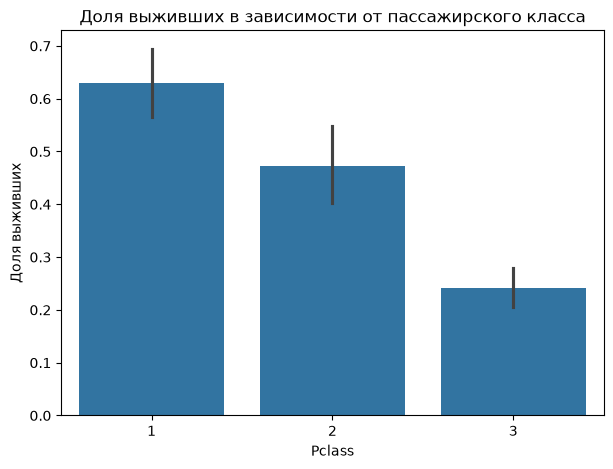

In [15]:
# Сравнение доли выживших в разных пассажирских классах 
plt.figure(figsize=(7, 5)) 

sns.barplot( 
    data = train, 
    x = "Pclass", 
    y = "Survived" 
) 

plt.title("Доля выживших в зависимости от пассажирского класса") 
plt.xlabel("Pclass") 
plt.ylabel("Доля выживших") 
plt.show()

### Вывод

Доля выживших **различается** между пассажирскими классами. Поэтому **Pclass** является значимым признаком для модели.

### 5.8. Выживаемость по порту посадки

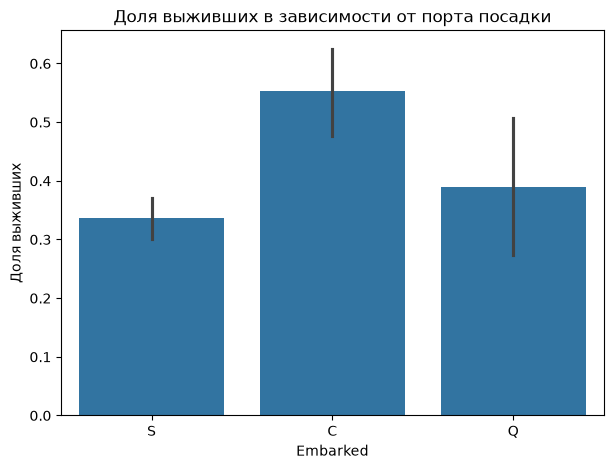

In [16]:
# Сравнение доли выживших в зависимости от порта посадки 
plt.figure(figsize=(7, 5)) 

sns.barplot( 
    data = train, 
    x = "Embarked", 
    y = "Survived" 
)  

plt.title("Доля выживших в зависимости от порта посадки") 
plt.xlabel("Embarked") 
plt.ylabel("Доля выживших") 
plt.show()

### Вывод

Доля выживших **отличается** между пассажирами, севшими в **разных портах**. При этом данный результат следует воспринимать как **статистическую зависимость конкретного датасета**, а не как доказательство причинного влияния порта посадки.

### 5.9. Обработка пропусков

In [17]:
# Создание копии исходных таблиц 
train_df = train.copy() 
test_df = test.copy()

# Расчёт медианы возраста только на обучающей выборке 
age_medians = train_df.groupby( 
    ["Pclass", "Sex"] 
)["Age"].median() 

overall_age_median = train_df["Age"].median()

# Создание функции безопасной импутации возраста
def fill_age(row): 
    if pd.isna(row["Age"]): 
        return age_medians.get( 
            (row["Pclass"], row["Sex"]), 
            overall_age_median ) 
    return row["Age"]

# Применение train-статистики к train и test 
train_df["Age"] = train_df.apply(fill_age, axis=1) 
test_df["Age"] = test_df.apply(fill_age, axis=1) 

# Нахождение наиболее частого порта посадки в train 
embarked_mode = train_df["Embarked"].mode()[0]

# Заполнение пропусков 
train_df["Embarked"] = train_df["Embarked"].fillna(embarked_mode) 
test_df["Embarked"] = test_df["Embarked"].fillna(embarked_mode) 

# Для Fare используется медиану train 
fare_median = train_df["Fare"].median() 
test_df["Fare"] = test_df["Fare"].fillna(fare_median)

# Удалене Cabin 
train_df = train_df.drop(columns=["Cabin"]) 
test_df = test_df.drop(columns=["Cabin"])

### 5.10. Feature Engineering

In [18]:
# Создание размера семьи 
train_df["Family_Size"] = ( train_df["SibSp"] + train_df["Parch"] + 1 )
test_df["Family_Size"] = ( test_df["SibSp"] + test_df["Parch"] + 1 )

# Создание индикатора путешествия в одиночку 
train_df["Is_Alone"] = ( train_df["Family_Size"] == 1 ).astype(int)
test_df["Is_Alone"] = ( test_df["Family_Size"] == 1 ).astype(int)

# Создание возрастных групп
age_bins = [0, 12, 18, 35, 60, np.inf] 
age_labels = [ "Child", "Teenager", "Adult", "Middle_Age", "Senior" ]

train_df["Age_Group"] = pd.cut( 
    train_df["Age"], 
    bins = age_bins, 
    labels = age_labels 
)

test_df["Age_Group"] = pd.cut( 
    test_df["Age"], 
    bins = age_bins,  
    labels = age_labels 
)

### 5.11. Кодирование

In [19]:
# Кодирование пола
sex_mapping = { 
    "male": 0, 
    "female": 1 
}

train_df["Sex_Encoded"] = train_df["Sex"].map(sex_mapping) 
test_df["Sex_Encoded"] = test_df["Sex"].map(sex_mapping)

# Выполнение One-Hot Encoding для Embarked 
train_embarked = pd.get_dummies( train_df["Embarked"], prefix="Embarked" )
test_embarked = pd.get_dummies( test_df["Embarked"], prefix="Embarked" )

# Выравнивание столбцов train и test 
test_embarked = test_embarked.reindex( columns=train_embarked.columns, fill_value=0 )

# Добавление закодированных признаков 
train_df = pd.concat( [train_df, train_embarked], axis=1 )
test_df = pd.concat( [test_df, test_embarked], axis=1 )

### Итоговые признаки

In [20]:
# Определение окончательного набора признаков 
feature_cols = [ 
    "Pclass", 
    "Sex_Encoded", 
    "Age", 
    "SibSp", 
    "Parch", 
    "Fare", 
    "Family_Size", 
    "Is_Alone", 
    "Embarked_Q", 
    "Embarked_S" 
]

# Итоговая таблица признаков 
display(train_df[feature_cols].head())

,Pclass,Sex_Encoded,Age,SibSp,Parch,Fare,Family_Size,Is_Alone,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,2,0,False,True
1,1,1,38.0,1,0,71.2833,2,0,False,False
2,3,1,26.0,0,0,7.9250,1,1,False,True
3,1,1,35.0,1,0,53.1000,2,0,False,True
4,3,0,35.0,0,0,8.0500,1,1,False,True


### Общий вывод по разделу 5
1) Выполнены все этапы EDA и подготовки данных.

2) Построено 7 визуализаций

3) Обработаны пропуски, созданы новые признаки, выполнено **Label Encoding** для Sex и **One-Hot Encoding** для Embarked.

4) Итоговый набор модели содержит 10 признаков.

## 6. Построение и обучение моделей

### 6.1. Рассматриваемые модели
**Для решения задачи используются две обязательные модели:**

1) Logistic Regression

2) Decision Tree.

**Logistic Regression** выбрана как интерпретируемая линейная модель.

**Decision Tree** позволяет моделировать нелинейные зависимости.

Для **Logistic Regression** применяется **StandardScaler**, для **Decision Tree** масштабирование не требуется.

### 6.2. Разделение данных

In [21]:
# Формирование матрицы признаков 
X = train_df[feature_cols] 

# Формируем целевую переменную 
y = train_df["Survived"] 

# Делим данные на train и test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

### 6.3. Реализация Logistic Regression

In [26]:
# Создание StandardScaler 
scaler = StandardScaler() 

# Обучение scaler только на train
X_train_scaled = scaler.fit_transform(X_train) 

# Применяем тот же scaler к test
X_test_scaled = scaler.transform(X_test) 

# Создание Logistic Regression 
lr_model = LogisticRegression( penalty="l2", C=1.0, max_iter=1000, random_state=42 ) 

# Время обучения 
start_time = time.perf_counter() 

lr_model.fit( X_train_scaled, y_train ) 
lr_train_time = time.perf_counter() - start_time 

print( f"Время обучения Logistic Regression: " f"{lr_train_time:.6f} сек." )

Время обучения Logistic Regression: 0.006762 сек.


c:\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### 6.4. Реализация Decision Tree

In [27]:
# Создание Decision Tree 
dt_model = DecisionTreeClassifier( max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42 ) 

# Время обучения 
start_time = time.perf_counter() 

dt_model.fit( X_train, y_train ) 
dt_train_time = time.perf_counter() - start_time 

print( f"Время обучения Decision Tree: " f"{dt_train_time:.6f} сек." )

Время обучения Decision Tree: 0.005606 сек.


### Общий вывод по разделу 6

Обе модели успешно обучены на одном и том же разбиении данных.

**Ориентировочное время обучения:**

1) **Logistic Regression** - около 0.006 с
2) **Decision Tree** - около 0.005 с.

Время зависит от оборудования и программного окружения.

## 7. Оценка качества

### 7.1. Прогнозирование

In [28]:
# Прогнозы Logistic Regression 
lr_pred = lr_model.predict( X_test_scaled ) 

# Вероятности Logistic Regression 
lr_proba = lr_model.predict_proba( X_test_scaled )[:, 1] 

# Прогнозы Decision Tree 
dt_pred = dt_model.predict( X_test ) 

# Вероятности Decision Tree 
dt_proba = dt_model.predict_proba( X_test )[:, 1]

### 7.2. Расчёт метрик

In [31]:
# Функция расчёта обязательных метрик 
def calculate_metrics(y_true, y_pred, y_proba): 
    return { 
        "Accuracy": accuracy_score( y_true, y_pred ), 
        "Precision": precision_score( y_true, y_pred ), 
        "Recall": recall_score( y_true, y_pred ), 
        "F1": f1_score( y_true, y_pred ), 
        "ROC-AUC": roc_auc_score( y_true, y_proba ) } 

# Рассчёт метрик
lr_metrics = calculate_metrics( y_test, lr_pred, lr_proba ) 
dt_metrics = calculate_metrics( y_test, dt_pred, dt_proba ) 

# Итоговую таблицу 
metrics_df = pd.DataFrame( [lr_metrics, dt_metrics], index=[ "Logistic Regression", "Decision Tree" ] ) 

display( metrics_df.round(4) )

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8486
Decision Tree,0.7821,0.7419,0.6667,0.7023,0.8132


### 7.3. Матрица ошибок для Logistic Regression

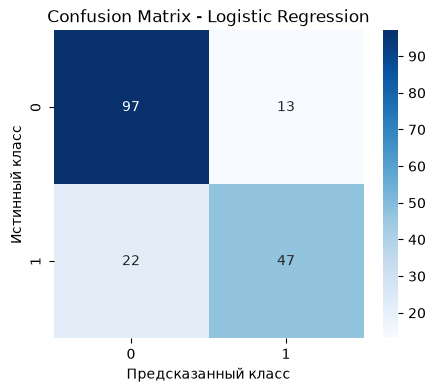

Матрица Logistic Regression:
[[97 13]
 [22 47]]


In [33]:
# Матрица ошибок Logistic Regression
lr_cm = confusion_matrix( y_test, lr_pred ) 

plt.figure(figsize=(5, 4)) 

sns.heatmap( lr_cm, annot=True, fmt="d", cmap="Blues" ) 

plt.title( "Confusion Matrix - Logistic Regression" ) 
plt.xlabel("Предсказанный класс") 
plt.ylabel("Истинный класс") 
plt.show() 

print( "Матрица Logistic Regression:" ) 
print(lr_cm)

### 7.4. Матрица ошибок для Decision Tree

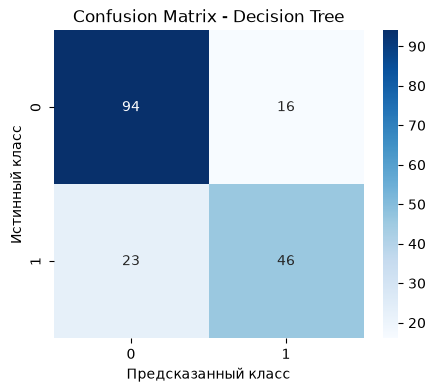

Матрица Decision Tree:
[[94 16]
 [23 46]]


In [34]:
# Матрица ошибок Decision Tree 
dt_cm = confusion_matrix( y_test, dt_pred ) 

plt.figure(figsize=(5, 4)) 

sns.heatmap( dt_cm, annot=True, fmt="d", cmap="Blues" ) 

plt.title( "Confusion Matrix - Decision Tree" ) 
plt.xlabel("Предсказанный класс") 
plt.ylabel("Истинный класс") 
plt.show() 

print( "Матрица Decision Tree:" ) 
print(dt_cm)

### 7.5. ROC-кривая

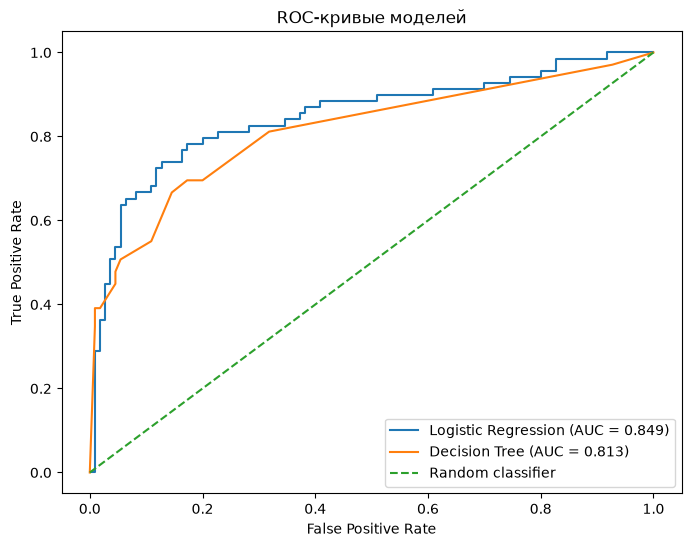

In [38]:
# Рассчёт ROC-кривых
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Обе ROC-кривые на одном графике
plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label = f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")

plt.plot(dt_fpr, dt_tpr, label = f"Decision Tree (AUC = {dt_metrics['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], linestyle = "--", label = "Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые моделей")
plt.legend()
plt.show()

### Общий вывод по разделу 7

Обе модели достигли ROC-AUC выше 0.80.

Logistic Regression показала следующие значения:

1) Accuracy - 0.804
2) Precision - 0.783
3) Recall - 0.681
4) F1 - 0.729
5) ROC-AUC - 0.849.

Decision Tree:

1) Accuracy - 0.782;
2) Precision - 0.742;
3) Recall - 0.667;
4) F1 - 0.702;
5) ROC-AUC - 0.813.


## 8. Интерпретация результатов
### 8.1. Коэффициенты Logistic Regression

In [37]:
# Rоэффициенты Logistic Regression 
lr_coefficients = pd.DataFrame({ "Feature": feature_cols, "Coefficient": lr_model.coef_[0] }) 

# Сортировка по величине коэффициента 
lr_coefficients = lr_coefficients.sort_values( "Coefficient", ascending=False ) 

display( lr_coefficients.round(4) )

,Feature,Coefficient
1,Sex_Encoded,1.2259
8,Embarked_Q,0.0881
5,Fare,0.0772
4,Parch,-0.0512
9,Embarked_S,-0.1292
6,Family_Size,-0.2238
7,Is_Alone,-0.2837
3,SibSp,-0.2948
2,Age,-0.5572
0,Pclass,-0.9713


### Интерпретация

Наиболее крупные по абсолютной величине коэффициенты получены для: **Sex_Encoded, Pclass, Age**.

Положительный коэффициент означает увеличение логарифма шансов класса 1 при прочих равных условиях, отрицательный - уменьшение.

Например, положительный коэффициент **Sex_Encoded** связан с увеличением шансов класса **Survived = 1** при переходе от **male = 0** к **female = 1** при прочих равных условиях.

### 8.2. Feature Importance Decision Tree

,Feature,Importance
1,Sex_Encoded,0.5477
0,Pclass,0.1862
5,Fare,0.1010
2,Age,0.0999
6,Family_Size,0.0493
3,SibSp,0.0132
4,Parch,0.0027
7,Is_Alone,0.0000
8,Embarked_Q,0.0000
9,Embarked_S,0.0000


Text(0.5, 1.0, 'Feature Importance - Decision Tree')

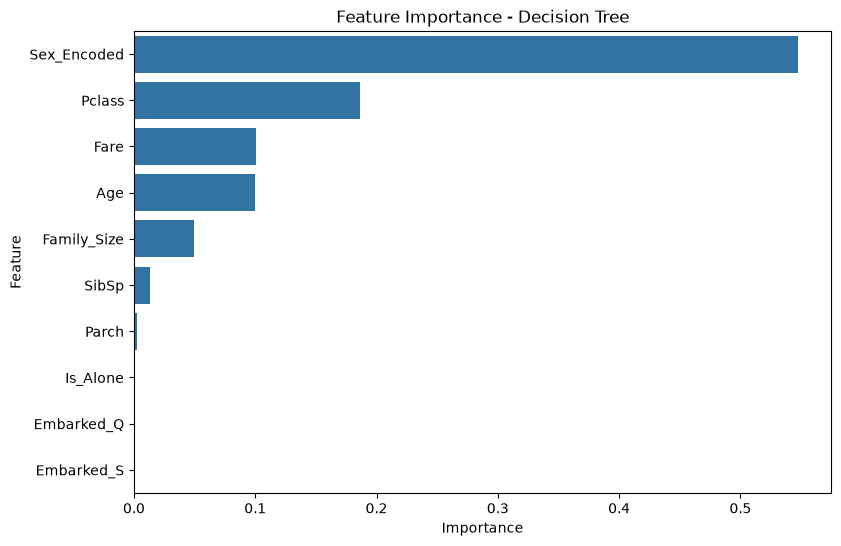

In [39]:
# Важность признаков Decision Tree 
dt_importance = pd.DataFrame({ "Feature": feature_cols, "Importance": dt_model.feature_importances_ }) 

# Сортировка признаков по важности 
dt_importance = dt_importance.sort_values( "Importance", ascending=False ) 

display( dt_importance.round(4) )

# Визуализация Feature Importance
plt.figure(figsize=(9, 6))

sns.barplot(data=dt_importance, x = "Importance", y = "Feature")

plt.title("Feature Importance - Decision Tree")

### Общий вывод по разделу 8

В рамках данного датасета наиболее информативными признаками оказались **Sex_Encoded и Pclass** (пол, пассажирский класс). Также заметную роль играют возраст и стоимость билета.
Это может использоваться как аналитический вывод о структуре данных Titanic.

При этом результаты модели показывают **статистические зависимости**, а не доказывают причинно-следственные связи.

**Logistic Regression** позволяет интерпретировать направление связи через коэффициенты,
а **Decision Tree** - относительный вклад признаков в процесс разбиения объектов.

## 9. Функция прогнозирования

Необходимо создать функцию **predict_passenger()**, которая получает данные нового пассажира и возвращает класс и вероятность для обеих моделей.

In [41]:
# Функция прогнозирования нового пассажира
def predict_passenger(pclass, sex, age, sibsp, parch, fare, embarked):
    
    # Кодирование пола
    sex_encoded = sex_mapping[sex]

    # Рассчёт размера семьи
    family_size = ( sibsp + parch + 1 )

    # Определяет, путешествует ли пассажир один
    is_alone = int(family_size == 1)

    # Кодирование Embarked
    embarked_q = int(embarked == "Q")

    embarked_s = int(embarked == "S")

    # Создание DataFrame с признаками
    data = pd.DataFrame([[
        pclass,
        sex_encoded,
        age,
        sibsp,
        parch,
        fare,
        family_size,
        is_alone,
        embarked_q,
        embarked_s
    ]], columns=feature_cols)

    # Масштабирование данных для Logistic Regression
    data_scaled = scaler.transform( data )

    # Вероятность выживания
    lr_probability = (lr_model.predict_proba( data_scaled )[0, 1]) 
    dt_probability = (dt_model.predict_proba( data )[0, 1])

    # Возвращает класс и вероятность
    return {
        "Logistic Regression": {
            "class": int(
                lr_probability >= 0.5
            ),
            "probability": float(
                lr_probability
            )
        },
        "Decision Tree": {
            "class": int(
                dt_probability >= 0.5
            ),
            "probability": float(
                dt_probability
            )
        }
    }

# Примеры
examples = [
    (1, 'female', 25, 1, 0, 100, 'C'),
    (3, 'male', 30, 0, 0, 7.25, 'S'),
    (2, 'female', 5, 3, 1, 30, 'S'),
    (1, 'male', 60, 0, 0, 200, 'C'),
    (3, 'female', 22, 0, 0, 8, 'Q')
]

# Вывод результата прогнозирования для примеров
for i, args in enumerate(examples, 1):
    r = predict_passenger(*args)
    print(f"\nПример {i}:")
    print(f"Logistic Regression: класс = {r['Logistic Regression']['class']}, вероятность = {r['Logistic Regression']['probability']:.3f}")
    print(f"Decision Tree: класс = {r['Decision Tree']['class']}, вероятность = {r['Decision Tree']['probability']:.3f}")


Пример 1:
Logistic Regression: класс = 1, вероятность = 0.961
Decision Tree: класс = 1, вероятность = 1.000

Пример 2:
Logistic Regression: класс = 0, вероятность = 0.076
Decision Tree: класс = 0, вероятность = 0.110

Пример 3:
Logistic Regression: класс = 1, вероятность = 0.808
Decision Tree: класс = 1, вероятность = 1.000

Пример 4:
Logistic Regression: класс = 0, вероятность = 0.306
Decision Tree: класс = 0, вероятность = 0.309

Пример 5:
Logistic Regression: класс = 1, вероятность = 0.735
Decision Tree: класс = 1, вероятность = 0.535


### Общий вывод по разделу 9

Функция **predict_passenger()** успешно формирует необходимые признаки нового объекта и возвращает результаты двух моделей.

В пяти демонстрационных примерах обе модели дали **одинаковый итоговый класс**, однако **значения вероятностей различаются**.

## 10. Сохранение модели

Модели необходимо сохранить через **joblib в формате .pkl**.

Также сохраняются метаданные в **.json**.

In [42]:
# Сохранение Logistic Regression
joblib.dump(
    lr_model,
    "models/lr_model.pkl"
)

# Сохранение Decision Tree
joblib.dump(
    dt_model,
    "models/dt_model.pkl"
)

# Сохранение scaler
joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Модели сохранены.")

# Сохранение порядка признаков
with open("models/feature_cols.json", "w", encoding="utf-8") as file:
    json.dump(feature_cols, file, ensure_ascii=False, indent=4)

# Сохранение mapping для пола
with open("models/sex_mapping.json", "w", encoding="utf-8") as file:
    json.dump(sex_mapping, file, ensure_ascii=False, indent=4)

# Сохранение метрики
with open("models/metrics.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "Logistic Regression": lr_metrics,
            "Decision Tree": dt_metrics
        },
        file,
        ensure_ascii=False,
        indent=4
    )

Модели сохранены.


### Вывод по разделу 10

В результате были созданы файлы: lr_model.pkl, dt_model.pkl, scaler.pkl, feature_cols.json, sex_mapping.json, metrics.json в папке models

# 11. Загрузка модели из репозитория
## 11.1. Загрузка модели

In [ ]:
# Указать базовый адрес
BASE_URL = ( 
    "https://raw.githubusercontent.com/" 
    "ZhdanovaAnna/ml-course-zhdanova/main/" 
    "module-1-titanic" 
)